In [1]:
import pandas as pd

geological = pd.read_csv(
    "../../data/synthetic/geological.csv"
)

geological.head()

,sample_id,latitude,longitude,elevation_m,slope_deg,aspect_deg,depth_m,formation,mn_pct,fe_pct,sio2_pct,ore_thickness_m,is_manganese
0,GS00000,21.349816,80.257454,545.849681,15.119566,242.806062,25.173746,Gondite,14.446323,15.631606,42.629756,1.889453,0
1,GS00001,21.580286,80.289374,571.236973,1.985030,106.004481,66.009310,Quartzite,8.576719,5.449597,28.014644,1.224468,0
2,GS00002,21.492798,80.441819,677.217324,20.583248,190.346764,6.352660,Laterite,18.724152,11.507052,21.852211,0.284538,0
3,GS00003,21.439463,80.236002,567.828867,26.470322,302.445418,26.067742,Manganiferous_Formation,37.339898,2.240470,37.137278,7.273265,1
4,GS00004,21.262407,80.447860,727.884401,14.465940,24.554245,35.868009,Gondite,1.279817,18.658449,63.171793,1.298407,0


In [2]:
geological.shape

(5000, 13)

In [3]:
geological.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        5000 non-null   str    
 1   latitude         5000 non-null   float64
 2   longitude        5000 non-null   float64
 3   elevation_m      5000 non-null   float64
 4   slope_deg        5000 non-null   float64
 5   aspect_deg       5000 non-null   float64
 6   depth_m          5000 non-null   float64
 7   formation        5000 non-null   str    
 8   mn_pct           5000 non-null   float64
 9   fe_pct           5000 non-null   float64
 10  sio2_pct         5000 non-null   float64
 11  ore_thickness_m  5000 non-null   float64
 12  is_manganese     5000 non-null   int64  
dtypes: float64(10), int64(1), str(2)
memory usage: 507.9 KB


In [4]:
geological.describe()

,latitude,longitude,elevation_m,slope_deg,aspect_deg,depth_m,mn_pct,fe_pct,sio2_pct,ore_thickness_m,is_manganese
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,21.398733,80.296595,649.838682,17.860973,181.991343,39.496081,17.724642,14.123358,33.131326,3.121986,0.35020
std,0.115853,0.114247,68.993535,10.036609,103.346787,22.984274,10.794998,5.128966,12.776509,3.647532,0.47708
min,21.200005,80.100021,375.431982,0.008836,0.017325,0.005400,0.000000,2.000000,5.000000,0.100000,0.00000
25%,21.297545,80.198858,604.220072,9.423465,92.942041,19.463786,9.797339,10.575444,24.266385,0.626111,0.00000
50%,21.400003,80.294389,649.733180,18.012375,182.959896,39.636704,16.110402,14.216841,33.290303,1.450440,0.00000
75%,21.499240,80.393349,695.551950,26.345704,270.086882,59.228660,23.650019,17.585817,41.786144,4.654352,1.00000
max,21.599887,80.499802,886.443777,34.996534,359.876271,79.978567,55.000000,31.401498,77.438380,20.000000,1.00000


In [5]:
geological["is_manganese"].value_counts()

is_manganese
0    3249
1    1751
Name: count, dtype: int64

In [6]:
geological["is_manganese"].value_counts(
    normalize=True
)

is_manganese
0    0.6498
1    0.3502
Name: proportion, dtype: float64

In [7]:
geological.groupby(
    "is_manganese"
)[["mn_pct", "fe_pct", "sio2_pct"]].mean()

,mn_pct,fe_pct,sio2_pct
is_manganese,,,
0,13.832040,14.457425,35.263622
1,24.947409,13.503492,29.174828


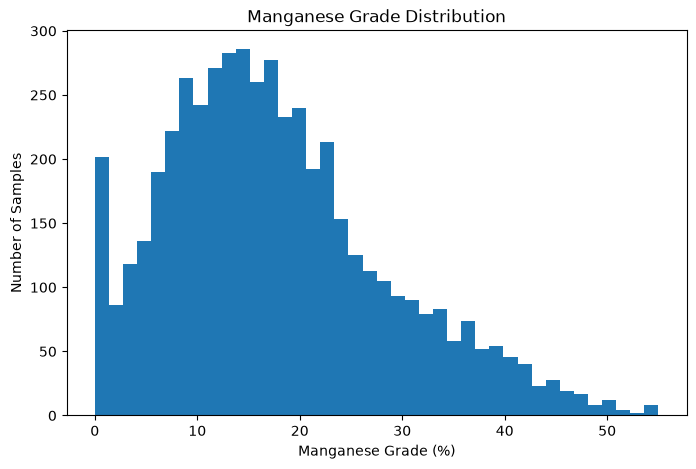

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    geological["mn_pct"],
    bins=40
)

plt.xlabel("Manganese Grade (%)")
plt.ylabel("Number of Samples")
plt.title("Manganese Grade Distribution")

plt.show()

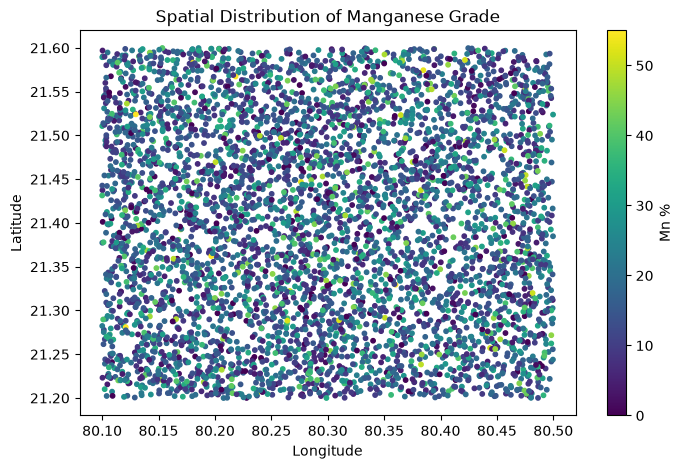

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(
    geological["longitude"],
    geological["latitude"],
    c=geological["mn_pct"],
    s=10
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Manganese Grade")

plt.colorbar(
    label="Mn %"
)

plt.show()

In [11]:
production = pd.read_csv(
    "../../data/synthetic/production.csv"
)

production.head()

,date,rainfall_mm,soil_moisture,temperature_c,vegetation_index,operating_hours,downtime_hours,utilization,planned_blasts,blasting_delay_hours,delay_reason,production_mt,target_mt,shortfall,production_gap_mt
0,2023-01-01,0.319792,0.196567,24.570255,0.298073,67.645401,17.100241,0.704640,0,0.177448,Equipment,6637.555730,8252.844597,1,1615.288867
1,2023-01-02,2.372774,0.295124,27.944407,0.451022,62.624226,16.432308,0.652336,1,5.610108,Material_Availability,7060.205938,8472.534579,1,1412.328640
2,2023-01-03,0.101778,0.272149,27.187180,0.244054,65.577574,9.620522,0.683100,0,0.450271,NaN,7552.995483,8698.087224,1,1145.091741
3,2023-01-04,6.598482,0.256947,26.282742,0.326838,61.036627,24.759319,0.635798,2,2.646605,Equipment,6099.608045,9040.735304,1,2941.127260
4,2023-01-05,0.440661,0.239192,27.923041,0.391575,63.374072,11.261409,0.660147,0,0.292736,Weather,8452.391898,8268.714462,0,-183.677436


In [12]:
production.describe()

,rainfall_mm,soil_moisture,temperature_c,vegetation_index,operating_hours,downtime_hours,utilization,planned_blasts,blasting_delay_hours,production_mt,target_mt,shortfall,production_gap_mt
count,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000
mean,4.672454,0.265405,27.959705,0.432026,64.071216,13.231205,0.667409,1.179745,1.440437,7203.166267,8491.509625,0.958942,1288.343358
std,6.147933,0.045777,4.749147,0.128560,4.309637,5.548629,0.044892,1.063976,1.436420,719.888854,201.029062,0.198516,753.050369
min,0.000554,0.135053,16.613811,0.197377,51.924699,3.126911,0.540882,0.000000,0.002551,5018.721610,7909.676909,0.000000,-1213.706887
25%,0.972298,0.232266,24.002193,0.333576,61.189882,9.338898,0.637395,0.000000,0.403543,6737.547244,8359.652612,1.000000,748.234916
50%,2.418268,0.264720,27.915010,0.382950,63.939271,11.844431,0.666034,1.000000,1.022249,7212.579079,8487.709049,1.000000,1303.593162
75%,5.446313,0.294437,31.890662,0.560836,66.967084,16.043147,0.697574,2.000000,1.996679,7707.927530,8627.517433,1.000000,1788.477608
max,45.092337,0.411259,39.105021,0.766597,78.700933,36.780771,0.819801,4.000000,8.744575,9348.950352,9095.432062,1.000000,3515.581091


In [13]:
production[
    [
        "production_mt",
        "target_mt",
        "rainfall_mm",
        "downtime_hours",
        "blasting_delay_hours"
    ]
].corr()

,production_mt,target_mt,rainfall_mm,downtime_hours,blasting_delay_hours
production_mt,1.000000,-0.029133,-0.156205,-0.530317,-0.216727
target_mt,-0.029133,1.000000,-0.024500,-0.023964,-0.019085
rainfall_mm,-0.156205,-0.024500,1.000000,-0.003427,0.006499
downtime_hours,-0.530317,-0.023964,-0.003427,1.000000,0.009069
blasting_delay_hours,-0.216727,-0.019085,0.006499,0.009069,1.000000


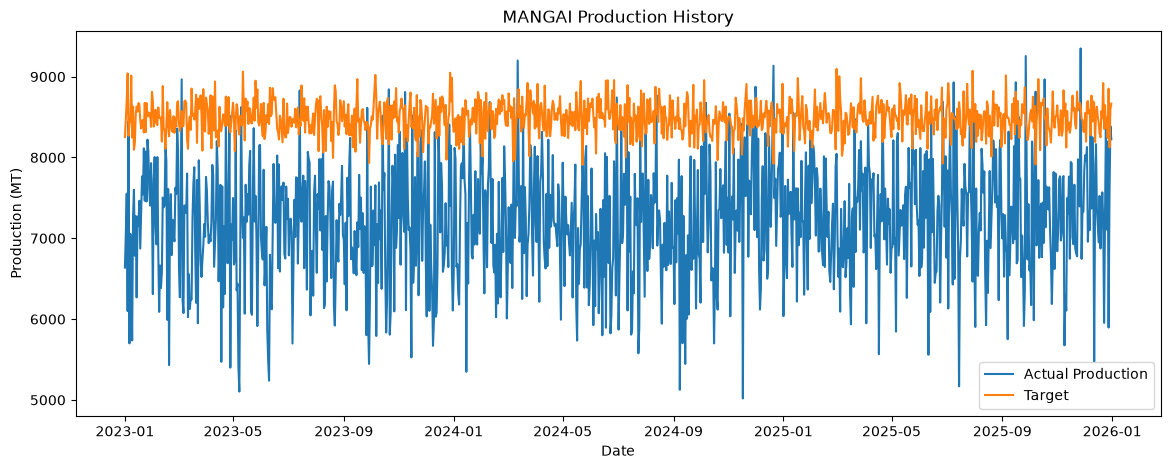

In [14]:
production["date"] = pd.to_datetime(
    production["date"]
)

plt.figure(figsize=(14, 5))

plt.plot(
    production["date"],
    production["production_mt"],
    label="Actual Production"
)

plt.plot(
    production["date"],
    production["target_mt"],
    label="Target"
)

plt.xlabel("Date")
plt.ylabel("Production (MT)")
plt.title("MANGAI Production History")

plt.legend()

plt.show()